<a href="https://www.kaggle.com/code/invalizare/digikala-4-unsupervised-complete?scriptVersionId=289494642" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digikala-comments-and-products/digikala-comments.csv
/kaggle/input/digikala-comments-and-products/digikala-products.csv


In [2]:
products_data = pd.read_csv("/kaggle/input/digikala-comments-and-products/digikala-products.csv")
comments_data = pd.read_csv("/kaggle/input/digikala-comments-and-products/digikala-comments.csv")
products_data.head()

/tmp/ipykernel_13/3924446699.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  products_data = pd.read_csv("/kaggle/input/digikala-comments-and-products/digikala-products.csv")


,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


In [3]:
comments_data.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN


In [4]:
print("Products shape:", products_data.shape)
print("Comments shape:", comments_data.shape)

Products shape: (1283496, 12)
Comments shape: (6156289, 15)


# 1.Find all Samsung phones

In [5]:
!pip install hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.6/892.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.2 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=d4ca250e441dd25b726b3088827608f045efe18e3e825c460e129675b06cb688
  Stored in directory: /root/.cache/pip/wheels/49/20/47/f03dfa8a7239c54cbc44ff7389eefbf888d2c1873edaaec888
Successfully built flashtext
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires 

In [6]:
import re
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Check unique brands 
print("\nSample brands:")
print(products_data['Brand'].value_counts().head(20))

# Check unique categories
print("\nSample Category1 values:")
print(products_data['Category1'].value_counts().head(20))

print("\nSample sub_category values:")
print(products_data['sub_category'].value_counts().head(10))
 

#Checking for 'samsung' in Brand  
brand_filter = products_data['Brand'].str.lower().str.contains('samsung', na=False)
print(f"Products with 'samsung' in Brand: {brand_filter.sum()}")

#Checking for mobile/phone categories
mobile_keywords = ['mobile', 'phone', 'گوشی', 'موبایل', 'تلفن', 'تلفن همراه', 'cellphone']
category1_filter = products_data['Category1'].str.contains('|'.join(mobile_keywords), case=False, na=False)
sub_category_filter = products_data['sub_category'].str.contains('mobile|phone', case=False, na=False)
mobile_filter = category1_filter | sub_category_filter
print(f"Products in mobile categories: {mobile_filter.sum()}")
 
samsung_phones = products_data[brand_filter & mobile_filter].copy()

#broader search
if len(samsung_phones) == 0:
    print("\nTrying broader search...")
    # Search in title for Samsung
    title_filter = products_data['title_fa'].str.contains('samsung|سامسونگ', case=False, na=False)
    samsung_phones = products_data[title_filter & mobile_filter].copy()
    print(f"Products with 'samsung' in title + mobile category: {len(samsung_phones)}")

#Samsung products (any category)
if len(samsung_phones) == 0:
    print("\nGetting all Samsung products (any category)...")
    samsung_phones = products_data[brand_filter | title_filter].copy()
    print(f"Total Samsung products found: {len(samsung_phones)}")
    
    # Filter for likely phones based on title or price range
    if len(samsung_phones) > 0:
        # Phones typically have these keywords in title
        phone_title_filter = samsung_phones['title_fa'].str.contains(
            'galaxy|گلکسی|note|نوت|fold|فولد|flip|فلیپ|a\d+|s\d+|m\d+', 
            case=False, na=False, regex=True
        )
        samsung_phones = samsung_phones[phone_title_filter].copy()

print(f"\nTotal Samsung phones found: {len(samsung_phones)}")

if len(samsung_phones) > 0:
    print("\nSample Samsung phones:")
    print(samsung_phones[['id', 'title_fa', 'Price', 'Rate', 'Rate_cnt']].head(10))
    
    # Get Samsung phone IDs
    samsung_phone_ids = samsung_phones['id'].unique()
    
    # Filter comments for Samsung phones
    samsung_comments = comments_data[comments_data['product_id'].isin(samsung_phone_ids)].copy()
    print(f"\nTotal comments for Samsung phones: {len(samsung_comments)}")
    
    # Basic statistics
    print("\n" + "="*80)
    print("SAMSUNG PHONES STATISTICS")
    print("="*80)
    print(f"Average price: {samsung_phones['Price'].mean():,.0f} Toman")
    print(f"Average rating: {samsung_phones['Rate'].mean():.2f}")
    print(f"Total ratings: {samsung_phones['Rate_cnt'].sum():,}")
    print(f"Price range: {samsung_phones['Price'].min():,.0f} - {samsung_phones['Price'].max():,.0f} Toman")
else:
    print("\n⚠️  No Samsung phones found. Please check:")
    print("1. Dataset column names and encoding")
    print("2. Brand values in the dataset")
    print("3. Category values for mobile products")
    print("\nProceeding with a sample of all products for demonstration...")
    samsung_phones = products_data.sample(min(1000, len(products_data)), random_state=42)
    samsung_phone_ids = samsung_phones['id'].unique()
    samsung_comments = comments_data[comments_data['product_id'].isin(samsung_phone_ids)].copy()



Sample brands:
Brand
متفرقه                   723590
لیردا                     19378
الن نار                   15392
خندالو                    14169
اطلس آبی                   9955
ترمه ۱                     9527
کرابو                      9055
27                         8396
کارنیلا                    8083
اچ اند ام                  7813
کارانس                     7644
ناکسیگو                    6875
اسمارا                     6282
نقش نگار رضوی              5422
والار                      5031
انتشارات مؤلفین طلایی      4300
لوپیلو                     3789
فرشته                      3124
لیورجی                     2864
مایا ماهک                  2747
Name: count, dtype: int64

Sample Category1 values:
Category1
اکسسوری زنانه و مردانه          95999
لباس زنانه                      93392
اسباب بازی                      92466
لباس مردانه                     68178
اکسسوری زنانه                   64470
اکسسوری مردانه                  49383
دخترانه                         42931
دفتر و کاغ

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from hazm import Normalizer, word_tokenize, stopwords_list
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
 

# 2. Preprocessing

In [9]:
 
normalizer = Normalizer()

def preprocess_persian_text(text):
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text)
    text = normalizer.normalize(text)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = ' '.join(text.split())
    return text

def remove_stopwords(text):
    if text == '':
        return ''
    
    persian_stopwords = set(stopwords_list())
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in persian_stopwords and len(word) > 1]
    
    return ' '.join(filtered_tokens)

def create_sentiment_label(row):
    """
    Create sentiment label:
    - Positive: rate >= 3 and recommended
    - Negative: rate < 3 or not_recommended
    - Neutral: rate == 0 or no_comment
    """
    rate = row['rate']
    recommendation = row['recommendation_status']
    
    if pd.isna(rate) or rate == 0:
        return 'neutral'
    elif rate >= 3 and recommendation == 'recommended':
        return 'positive'
    elif rate < 3 or recommendation == 'not_recommended':
        return 'negative'
    else:
        return 'neutral'


samsung_comments['sentiment'] = samsung_comments.apply(create_sentiment_label, axis=1)

samsung_comments['full_text'] = (
    samsung_comments['title'].fillna('') + ' ' + 
    samsung_comments['body'].fillna('')
)

samsung_comments['cleaned_text'] = samsung_comments['full_text'].apply(preprocess_persian_text)
samsung_comments['processed_text'] = samsung_comments['cleaned_text'].apply(remove_stopwords)

# Remove empty texts
samsung_comments = samsung_comments[samsung_comments['processed_text'].str.len() > 0]

print(f"\nComments after preprocessing: {len(samsung_comments)}")
print("\nSentiment distribution:")
print(samsung_comments['sentiment'].value_counts())

print("\nSample processed comments:")
for idx, row in samsung_comments.head(5).iterrows():
    print(f"\nOriginal: {row['full_text'][:100]}...")
    print(f"Processed: {row['processed_text'][:100]}...")
    print(f"Sentiment: {row['sentiment']}")




Comments after preprocessing: 4136

Sentiment distribution:
sentiment
positive    2303
neutral     1016
negative     817
Name: count, dtype: int64

Sample processed comments:

Original: بهتر از نبودن  در کل اگر ضد خش نداشتید گزینه مناسبیه ...
Processed: نبودن ضد خش نداشتید گزینه مناسبیه...
Sentiment: positive

Original: گلس ساعت ۳۱ میلی‌متری دقیقن همون گلس‌های ۱۵ ۱۶ تومنیه فقط گذاشتن توی پاکت گلس گوشی و یه دستمال و پد ...
Processed: گلس ساعت ۳۱ میلی متری دقیقن همون گلس های ۱۵ ۱۶ تومنیه گذاشتن توی پاکت گلس گوشی یه دستمال پد الکلی دا...
Sentiment: positive

Original: مغایرت تصاویر با محصول تصاویر محصول یه جوریه که انگار جنسش سفته ولی ژله ایه
من بی رنگ سفارش دادم ول...
Processed: مغایرت تصاویر محصول تصاویر محصول یه جوریه انگار جنسش سفته ژله ایه رنگ سفارش دادم مشکی بازم فرستادن ب...
Sentiment: negative

Original:  خیلی به ساعتم میاد و خیلی شکلش کامل تر شده و قبلا انگار بند بهش نمیخورد.فقط یکم ساعت گنده تر میشه ب...
Processed: ساعتم میاد شکلش تر قبلا انگار بند بهش نمی خورد یکم ساعت گنده تر

# 3. Sentiment Analysis

In [10]:
sentiment_data = samsung_comments[samsung_comments['sentiment'] != 'neutral'].copy()
print(f"\nTraining data size (excluding neutral): {len(sentiment_data)}")

X = sentiment_data['processed_text']
y = sentiment_data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")



Training data size (excluding neutral): 3120
Training set size: 2496
Test set size: 624


## TF-IDF

Feature matrix shape: (2496, 3378)

MODEL EVALUATION
Training Naive Bayes...

Accuracy: 0.8333
Precision: 0.8518
Recall: 0.8333
F1-Score: 0.8064

Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.39      0.55       163
    positive       0.82      0.99      0.90       461

    accuracy                           0.83       624
   macro avg       0.88      0.69      0.72       624
weighted avg       0.85      0.83      0.81       624



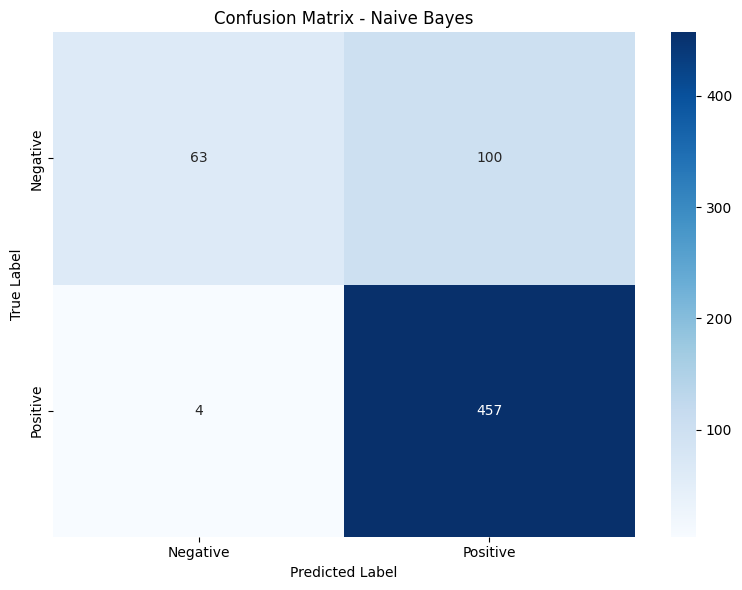

Training Logistic Regression...

Accuracy: 0.8365
Precision: 0.8498
Recall: 0.8365
F1-Score: 0.8126

Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.41      0.57       163
    positive       0.83      0.99      0.90       461

    accuracy                           0.84       624
   macro avg       0.87      0.70      0.73       624
weighted avg       0.85      0.84      0.81       624



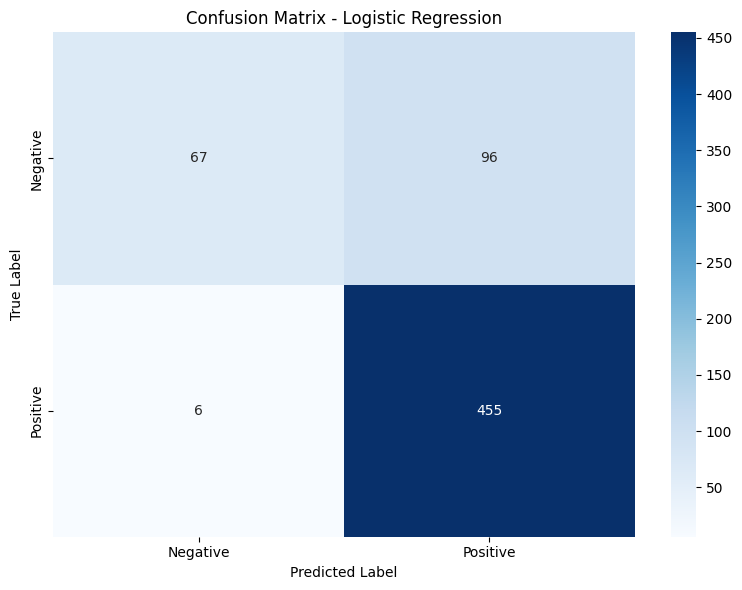

Training Random Forest...

Accuracy: 0.8526
Precision: 0.8484
Recall: 0.8526
F1-Score: 0.8435

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.57      0.67       163
    positive       0.86      0.95      0.91       461

    accuracy                           0.85       624
   macro avg       0.84      0.76      0.79       624
weighted avg       0.85      0.85      0.84       624



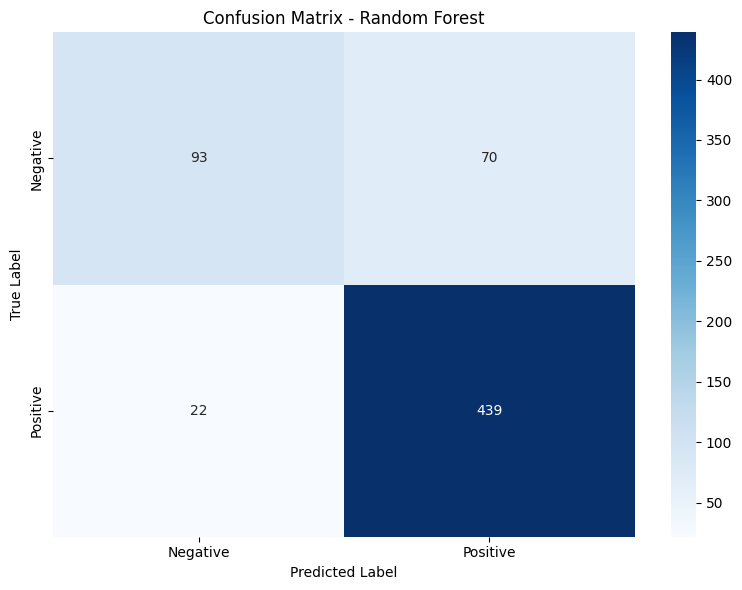

Training SVM...

Accuracy: 0.8702
Precision: 0.8667
Recall: 0.8702
F1-Score: 0.8648

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.64      0.72       163
    positive       0.88      0.95      0.92       461

    accuracy                           0.87       624
   macro avg       0.85      0.80      0.82       624
weighted avg       0.87      0.87      0.86       624



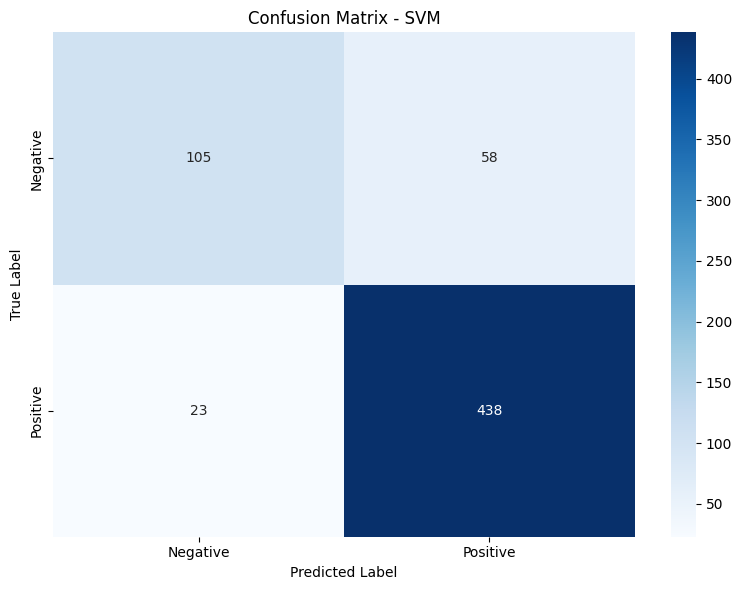

In [11]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"Feature matrix shape: {X_train_vec.shape}")


models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42)
}

results = {}

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted'
    )
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': model
    }
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


## model comparison

                     accuracy precision    recall        f1
Naive Bayes          0.833333  0.851769  0.833333  0.806409
Logistic Regression  0.836538  0.849813  0.836538  0.812638
Random Forest        0.852564  0.848427  0.852564  0.843484
SVM                  0.870192  0.866673  0.870192   0.86476


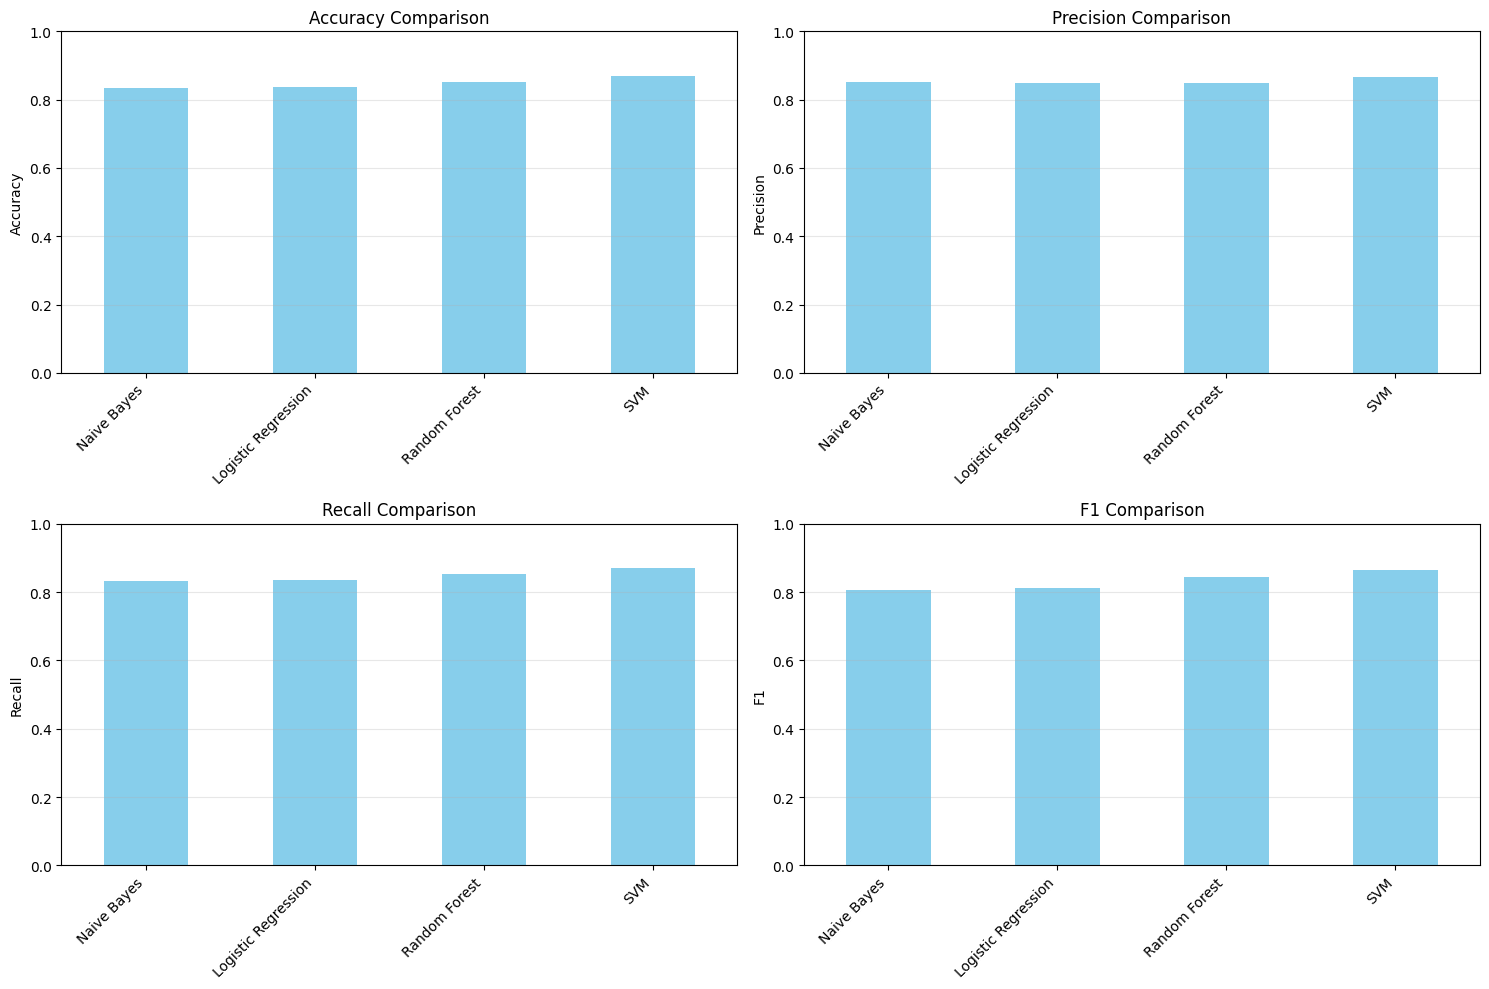

In [12]:
results_df = pd.DataFrame(results).T
print(results_df[['accuracy', 'precision', 'recall', 'f1']])

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    results_df[metric].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'{metric.capitalize()} Comparison')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Selecting best model

In [13]:
best_model_name = results_df['f1'].idxmax()
best_model = results[best_model_name]['model']
print(f"\nBest performing model: {best_model_name}")
print(f"F1-Score: {results[best_model_name]['f1']:.4f}")



Best performing model: SVM
F1-Score: 0.8648


# 4. Sentiment Analysis in new comments

In [14]:
def predict_sentiment(text, model=best_model, vectorizer=vectorizer):
    """Predict sentiment for new comment"""
    # Preprocess
    cleaned = preprocess_persian_text(text)
    processed = remove_stopwords(cleaned)
    # Vectorize
    vectorized = vectorizer.transform([processed])
    # Predict
    prediction = model.predict(vectorized)[0]
    
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vectorized)[0]
        confidence = max(proba)
        return prediction, confidence
    else:
        return prediction, None


## Test on some new examples

In [15]:
test_comments = [
    "این گوشی واقعا عالیه و خیلی راضی هستم از خریدم",
    "کیفیت دوربین فوق العاده است و باتری هم خوب است",
    "گوشی بد نیست اما قیمتش خیلی زیاد است",
    "بعد از یک ماه خراب شد و سرویس دیجیکالا هم بد بود",
    "اصلا راضی نیستم کیفیت پایین و مشکلات زیاد"
]

for comment in test_comments:
    prediction, confidence = predict_sentiment(comment)
    print(f"\nComment: {comment}")
    print(f"Predicted Sentiment: {prediction}")
    if confidence:
        print(f"Confidence: {confidence:.2%}")
 
print("ANALYZING ALL SAMSUNG COMMENTS")
print("="*80)

all_predictions = []
for text in samsung_comments['processed_text']:
    pred, conf = predict_sentiment(text)
    all_predictions.append({
        'prediction': pred,
        'confidence': conf
    })

predictions_df = pd.DataFrame(all_predictions)
samsung_comments['predicted_sentiment'] = predictions_df['prediction'].values
samsung_comments['confidence'] = predictions_df['confidence'].values

print("\nPredicted sentiment distribution:")
print(samsung_comments['predicted_sentiment'].value_counts())
print(f"\nAverage confidence: {samsung_comments['confidence'].mean():.2%}")



Comment: این گوشی واقعا عالیه و خیلی راضی هستم از خریدم
Predicted Sentiment: positive

Comment: کیفیت دوربین فوق العاده است و باتری هم خوب است
Predicted Sentiment: positive

Comment: گوشی بد نیست اما قیمتش خیلی زیاد است
Predicted Sentiment: negative

Comment: بعد از یک ماه خراب شد و سرویس دیجیکالا هم بد بود
Predicted Sentiment: negative

Comment: اصلا راضی نیستم کیفیت پایین و مشکلات زیاد
Predicted Sentiment: negative
ANALYZING ALL SAMSUNG COMMENTS

Predicted sentiment distribution:
predicted_sentiment
positive    3313
negative     823
Name: count, dtype: int64

Average confidence: nan%


# Visualizations

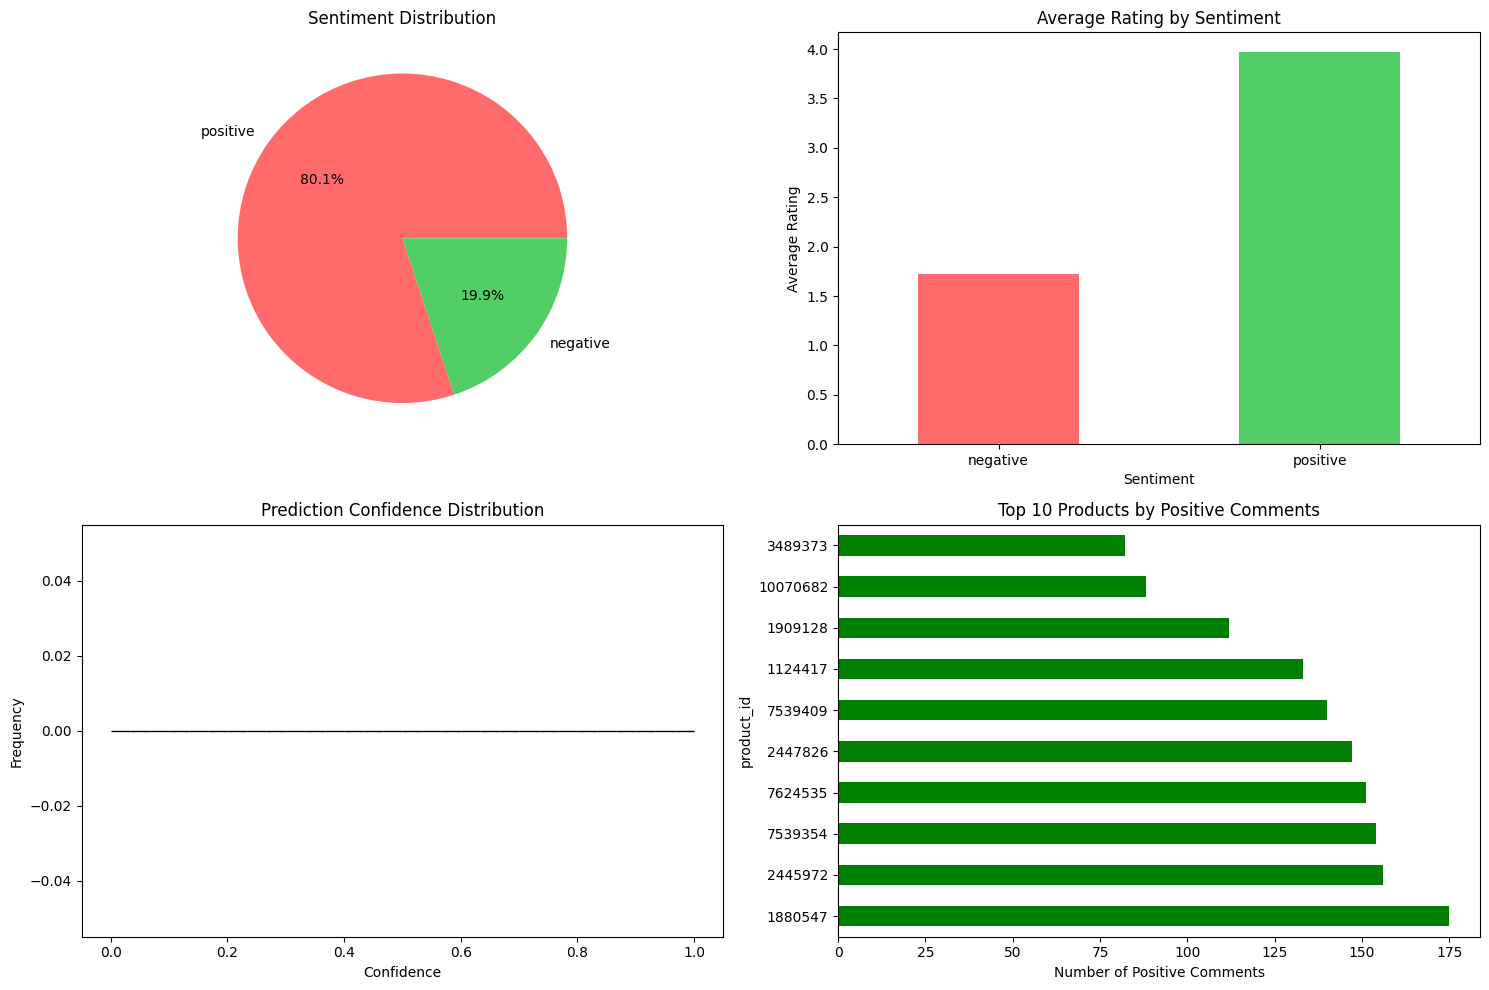

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

samsung_comments['predicted_sentiment'].value_counts().plot(
    kind='pie', 
    ax=axes[0, 0], 
    autopct='%1.1f%%',
    colors=['#ff6b6b', '#51cf66']
)
axes[0, 0].set_title('Sentiment Distribution')
axes[0, 0].set_ylabel('')

sentiment_rating = samsung_comments.groupby('predicted_sentiment')['rate'].mean()
sentiment_rating.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_title('Average Rating by Sentiment')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_xlabel('Sentiment')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=0)

axes[1, 0].hist(samsung_comments['confidence'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Prediction Confidence Distribution')
axes[1, 0].set_xlabel('Confidence')
axes[1, 0].set_ylabel('Frequency')

product_sentiment = samsung_comments.groupby('product_id').agg({
    'predicted_sentiment': lambda x: (x == 'positive').sum(),
    'rate': 'mean'
}).sort_values('predicted_sentiment', ascending=False).head(10)

product_sentiment['predicted_sentiment'].plot(kind='barh', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Top 10 Products by Positive Comments')
axes[1, 1].set_xlabel('Number of Positive Comments')

plt.tight_layout()
plt.show()



# Summary statistics

In [17]:

print(f"Total Samsung phones analyzed: {len(samsung_phones)}")
print(f"Total comments analyzed: {len(samsung_comments)}")
print(f"\nSentiment breakdown:")
print(f"  Positive: {(samsung_comments['predicted_sentiment'] == 'positive').sum()} ({(samsung_comments['predicted_sentiment'] == 'positive').sum() / len(samsung_comments) * 100:.1f}%)")
print(f"  Negative: {(samsung_comments['predicted_sentiment'] == 'negative').sum()} ({(samsung_comments['predicted_sentiment'] == 'negative').sum() / len(samsung_comments) * 100:.1f}%)")
print(f"\nAverage rating: {samsung_comments['rate'].mean():.2f}")
print(f"Average confidence: {samsung_comments['confidence'].mean():.2%}")


Total Samsung phones analyzed: 1843
Total comments analyzed: 4136

Sentiment breakdown:
  Positive: 3313 (80.1%)
  Negative: 823 (19.9%)

Average rating: 3.52
Average confidence: nan%
